In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, roc_auc_score, roc_curve)
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

In [60]:
plt.style.use('seaborn-v0_8-whitegrid')
colors = {
    'default': '#E74C3C',
    'no_default': '#2ECC71',
    'netural': '#3498DB'
}

### ── SECTION 1: DATA LOADING & INSPECTION ─────────────────────────────────────

In [61]:
#DATA LOADING & INSPECTION 
df = pd.read_csv("raw_data_sample.csv")

print(f'\nRaw data shape: {df.shape[0]} rows x {df.shape[1]} columns')
print(f'\nMissing Values')
missing = df.isnull().sum()
# print(missing)
missing = missing[missing > 0]
missing_pct = (missing/len(df) * 100).round(2)
print(pd.DataFrame({'Missing': missing, 'pct%': missing_pct}).to_string())
print(f'\nDupicate rows: {df.duplicated().sum()}')
print(f'\nDefault rate (raw): {df['default_status'].mean():.1%}')


Raw data shape: 2010 rows x 29 columns

Missing Values
                   Missing  pct%
education               81  4.03
employment_status      140  6.97
months_employed        100  4.98
annual_income_inr       81  4.03
loan_purpose            61  3.03
interest_rate           41  2.04
credit_score           107  5.32
num_late_payments       61  3.03
dti_ratio              120  5.97

Dupicate rows: 6

Default rate (raw): 60.9%


### ── SECTION 2: DATA CLEANING ──────────────────────────────────────────────────

In [62]:
#DATA CLEANING
df_clean = df.copy()

In [63]:
df_clean.head()

,loan_id,applicant_name,pan_number,age,gender,city,state,education,employment_status,months_employed,...,application_date,credit_score,num_credit_lines,num_open_accounts,num_late_payments,dti_ratio,bankruptcies,loan_to_income_ratio,default_status,default_label
0,LN1000000,Namrata Tripathi,PZVIS6649L,28,Female,Surat,Gujarat,Diploma,Contract/Freelance,82.0,...,2023-08-02,689,10,12,2.0,34.50,0,0.6302,0,No Default
1,LN1000001,Varun Khanna,NVVWE0128Y,33,Male,Vadodara,Gujarat,Illiterate,Part-Time,39.0,...,2020-08-16,638,17,5,2.0,27.45,0,0.5364,1,Default
2,LN1000002,Pallavi Kulkarni,XYXRF2848L,27,Female,Nagpur,Maharashtra,Professional Degree,Salaried,35.0,...,2020-02-21,701,2,13,0.0,32.41,0,0.4188,0,No Default
3,LN1000003,Sonali Oberoi,GHWMW5908Q,31,Female,Meerut,Uttar Pradesh,12th Pass,Part-Time,61.0,...,2024-02-27,771,6,13,1.0,45.72,0,0.4201,1,Default
4,LN1000004,Jitendra Bhatt,DRNKW1939O,21,Male,Guwahati,Assam,Professional Degree,Retired,0.0,...,2021-07-17,631,5,2,2.0,54.17,0,1.6003,1,Default


In [64]:
# Remove duplicates
before = len(df_clean)
df_clean.drop_duplicates(inplace=True)
print(f'✅ Removed: {before - len(df_clean)} duplicate rows')

✅ Removed: 6 duplicate rows


In [65]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2004 entries, 0 to 2007
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   loan_id                   2004 non-null   object 
 1   applicant_name            2004 non-null   object 
 2   pan_number                2004 non-null   object 
 3   age                       2004 non-null   int64  
 4   gender                    2004 non-null   object 
 5   city                      2004 non-null   object 
 6   state                     2004 non-null   object 
 7   education                 1924 non-null   object 
 8   employment_status         1864 non-null   object 
 9   months_employed           1904 non-null   float64
 10  annual_income_inr         1924 non-null   float64
 11  annual_income_stated_inr  2004 non-null   int64  
 12  property_ownership        2004 non-null   object 
 13  loan_id_duplicate         2004 non-null   object 
 14  loan_amount_i

In [66]:
# Drop duplicate column
df_clean.drop(columns=['loan_id_duplicate'], inplace=True)

In [67]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2004 entries, 0 to 2007
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   loan_id                   2004 non-null   object 
 1   applicant_name            2004 non-null   object 
 2   pan_number                2004 non-null   object 
 3   age                       2004 non-null   int64  
 4   gender                    2004 non-null   object 
 5   city                      2004 non-null   object 
 6   state                     2004 non-null   object 
 7   education                 1924 non-null   object 
 8   employment_status         1864 non-null   object 
 9   months_employed           1904 non-null   float64
 10  annual_income_inr         1924 non-null   float64
 11  annual_income_stated_inr  2004 non-null   int64  
 12  property_ownership        2004 non-null   object 
 13  loan_amount_inr           2004 non-null   int64  
 14  loan_purpose 

In [68]:
df_clean = df_clean.drop_duplicates(subset="loan_id", keep="first")

In [69]:
# Clean credit_score (stored as text)
df_clean['credit_score'] = pd.to_numeric(df_clean['credit_score'], errors='coerce')
df_clean.loc[df_clean['credit_score'] < 300, 'credit_score'] = np.nan
df_clean.loc[df_clean['credit_score'] > 900, 'credit_score'] = np.nan
print('✅ credit_score cleaned')

✅ credit_score cleaned


In [70]:
df_clean.head()

,loan_id,applicant_name,pan_number,age,gender,city,state,education,employment_status,months_employed,...,application_date,credit_score,num_credit_lines,num_open_accounts,num_late_payments,dti_ratio,bankruptcies,loan_to_income_ratio,default_status,default_label
0,LN1000000,Namrata Tripathi,PZVIS6649L,28,Female,Surat,Gujarat,Diploma,Contract/Freelance,82.0,...,2023-08-02,689.0,10,12,2.0,34.50,0,0.6302,0,No Default
1,LN1000001,Varun Khanna,NVVWE0128Y,33,Male,Vadodara,Gujarat,Illiterate,Part-Time,39.0,...,2020-08-16,638.0,17,5,2.0,27.45,0,0.5364,1,Default
2,LN1000002,Pallavi Kulkarni,XYXRF2848L,27,Female,Nagpur,Maharashtra,Professional Degree,Salaried,35.0,...,2020-02-21,701.0,2,13,0.0,32.41,0,0.4188,0,No Default
3,LN1000003,Sonali Oberoi,GHWMW5908Q,31,Female,Meerut,Uttar Pradesh,12th Pass,Part-Time,61.0,...,2024-02-27,771.0,6,13,1.0,45.72,0,0.4201,1,Default
4,LN1000004,Jitendra Bhatt,DRNKW1939O,21,Male,Guwahati,Assam,Professional Degree,Retired,0.0,...,2021-07-17,631.0,5,2,2.0,54.17,0,1.6003,1,Default


In [71]:
df_clean.rename(columns={'high_rick_flag': 'high_risk_flag'}, inplace=True)

In [72]:
# Fix age
df_clean.loc[(df_clean['age'] < 21) | (df_clean['age'] > 70), 'age'] = np.nan
df_clean['age'].fillna(df_clean['age'].median(), inplace= True)

In [73]:
df_clean.isnull().sum()

loan_id                       0
applicant_name                0
pan_number                    0
age                           0
gender                        0
city                          0
state                         0
education                    80
employment_status           140
months_employed             100
annual_income_inr            80
annual_income_stated_inr      0
property_ownership            0
loan_amount_inr               0
loan_purpose                 60
loan_grade                    0
interest_rate                40
loan_term_months              0
application_date              0
credit_score                125
num_credit_lines              0
num_open_accounts             0
num_late_payments            60
dti_ratio                   120
bankruptcies                  0
loan_to_income_ratio          0
default_status                0
default_label                 0
dtype: int64

In [74]:
# Fix negative loan amounts
df_clean.loc[df_clean['loan_amount_inr'] < 0, 'loan_amount_inr'] = df_clean.loc[df_clean['loan_amount_inr'] < 0, 'loan_amount_inr'].abs()

In [75]:
df_clean

,loan_id,applicant_name,pan_number,age,gender,city,state,education,employment_status,months_employed,...,application_date,credit_score,num_credit_lines,num_open_accounts,num_late_payments,dti_ratio,bankruptcies,loan_to_income_ratio,default_status,default_label
0,LN1000000,Namrata Tripathi,PZVIS6649L,28.0,Female,Surat,Gujarat,Diploma,Contract/Freelance,82.0,...,2023-08-02,689.0,10,12,2.0,34.50,0,0.6302,0,No Default
1,LN1000001,Varun Khanna,NVVWE0128Y,33.0,Male,Vadodara,Gujarat,Illiterate,Part-Time,39.0,...,2020-08-16,638.0,17,5,2.0,27.45,0,0.5364,1,Default
2,LN1000002,Pallavi Kulkarni,XYXRF2848L,27.0,Female,Nagpur,Maharashtra,Professional Degree,Salaried,35.0,...,2020-02-21,701.0,2,13,0.0,32.41,0,0.4188,0,No Default
3,LN1000003,Sonali Oberoi,GHWMW5908Q,31.0,Female,Meerut,Uttar Pradesh,12th Pass,Part-Time,61.0,...,2024-02-27,771.0,6,13,1.0,45.72,0,0.4201,1,Default
4,LN1000004,Jitendra Bhatt,DRNKW1939O,21.0,Male,Guwahati,Assam,Professional Degree,Retired,0.0,...,2021-07-17,631.0,5,2,2.0,54.17,0,1.6003,1,Default
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,LN1001995,Hemant Bansal,OQEMG4731M,35.0,Male,Kolkata,West Bengal,10th Pass,Part-Time,12.0,...,2020-08-23,735.0,11,11,3.0,54.52,0,3.4695,1,Default
1996,LN1001996,Jyoti Krishnan,ZKVOB4893H,21.0,Female,Chandigarh,Punjab,Post-Graduate,Unemployed,5.0,...,2024-04-10,647.0,8,13,1.0,5.02,0,0.5155,0,No Default
1997,LN1001997,Parth Shukla,WNQKH2732S,31.0,Male,Ghaziabad,Uttar Pradesh,12th Pass,NaN,NaN,...,2021-07-24,579.0,10,14,4.0,24.42,0,0.9473,1,Default
1998,LN1001998,Disha Tiwari,SEWUY9376K,51.0,Female,Nashik,Maharashtra,Diploma,Self-Employed,27.0,...,2023-03-21,NaN,1,12,1.0,42.44,0,1.9665,1,Default


In [76]:
# Fix impossible DTI
df_clean.loc[(df_clean['dti_ratio'] < 0) | (df_clean['dti_ratio'] > 200), 'dti_ratio'] = np.nan

In [77]:
df_clean.isnull().sum()

loan_id                       0
applicant_name                0
pan_number                    0
age                           0
gender                        0
city                          0
state                         0
education                    80
employment_status           140
months_employed             100
annual_income_inr            80
annual_income_stated_inr      0
property_ownership            0
loan_amount_inr               0
loan_purpose                 60
loan_grade                    0
interest_rate                40
loan_term_months              0
application_date              0
credit_score                125
num_credit_lines              0
num_open_accounts             0
num_late_payments            60
dti_ratio                   127
bankruptcies                  0
loan_to_income_ratio          0
default_status                0
default_label                 0
dtype: int64

In [78]:
# Fix income errors (entered 100x too high — paise instead of rupees)
income_cap = 10_000_000
df_clean.loc[df_clean['annual_income_inr'] > income_cap, 'annual_income_inr'] = df_clean.loc[df_clean['annual_income_inr'] > income_cap, 'annual_income_inr']/100
print(f"✅ Income data entry errors corrected")

✅ Income data entry errors corrected


In [79]:
# Standardise gender
gender_map = {
    'M': 'Male', 'F': 'Female',
    'male': 'Male', 'female': 'Female',
    'MALE': 'Male', 'FEMALE': 'Female'
}
df_clean['gender'] = df_clean['gender'].replace(gender_map)

In [80]:
df_clean

,loan_id,applicant_name,pan_number,age,gender,city,state,education,employment_status,months_employed,...,application_date,credit_score,num_credit_lines,num_open_accounts,num_late_payments,dti_ratio,bankruptcies,loan_to_income_ratio,default_status,default_label
0,LN1000000,Namrata Tripathi,PZVIS6649L,28.0,Female,Surat,Gujarat,Diploma,Contract/Freelance,82.0,...,2023-08-02,689.0,10,12,2.0,34.50,0,0.6302,0,No Default
1,LN1000001,Varun Khanna,NVVWE0128Y,33.0,Male,Vadodara,Gujarat,Illiterate,Part-Time,39.0,...,2020-08-16,638.0,17,5,2.0,27.45,0,0.5364,1,Default
2,LN1000002,Pallavi Kulkarni,XYXRF2848L,27.0,Female,Nagpur,Maharashtra,Professional Degree,Salaried,35.0,...,2020-02-21,701.0,2,13,0.0,32.41,0,0.4188,0,No Default
3,LN1000003,Sonali Oberoi,GHWMW5908Q,31.0,Female,Meerut,Uttar Pradesh,12th Pass,Part-Time,61.0,...,2024-02-27,771.0,6,13,1.0,45.72,0,0.4201,1,Default
4,LN1000004,Jitendra Bhatt,DRNKW1939O,21.0,Male,Guwahati,Assam,Professional Degree,Retired,0.0,...,2021-07-17,631.0,5,2,2.0,54.17,0,1.6003,1,Default
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,LN1001995,Hemant Bansal,OQEMG4731M,35.0,Male,Kolkata,West Bengal,10th Pass,Part-Time,12.0,...,2020-08-23,735.0,11,11,3.0,54.52,0,3.4695,1,Default
1996,LN1001996,Jyoti Krishnan,ZKVOB4893H,21.0,Female,Chandigarh,Punjab,Post-Graduate,Unemployed,5.0,...,2024-04-10,647.0,8,13,1.0,5.02,0,0.5155,0,No Default
1997,LN1001997,Parth Shukla,WNQKH2732S,31.0,Male,Ghaziabad,Uttar Pradesh,12th Pass,NaN,NaN,...,2021-07-24,579.0,10,14,4.0,24.42,0,0.9473,1,Default
1998,LN1001998,Disha Tiwari,SEWUY9376K,51.0,Female,Nashik,Maharashtra,Diploma,Self-Employed,27.0,...,2023-03-21,NaN,1,12,1.0,42.44,0,1.9665,1,Default


In [81]:
df_clean['loan_purpose'].head(20)

0           Wedding Expenses
1           Wedding Expenses
2             Education Fees
3         Business Expansion
4                     Travel
5                     Travel
6          Medical Emergency
7         Business Expansion
8         Debt Consolidation
9          Consumer Durables
10          Vehicle Purchase
11           Home Renovation
12         Consumer Durables
13            Education Fees
14        Credit Card Payoff
15          Vehicle Purchase
16          Vehicle Purchase
17          Vehicle Purchase
18          VEHICLE PURCHASE
19      Credit Card Payoff  
Name: loan_purpose, dtype: object

In [82]:
# Clean loan_purpose
df_clean['loan_purpose'] = (df_clean['loan_purpose'].str.strip().str.title())

In [83]:
# Parse mixed date formats
def parse_flexible_date(date_str):
    formate = ['%Y-%m-%d', '%Y/%m/%d', '%d-%m-%Y', '%d/%m/%Y', '%d %b %Y']
    for fmt in formate:
        try:
            return pd.to_datetime(date_str, format=fmt)
        except:
            pass
        return pd.NaT

df_clean['application_date'] = df_clean['application_date'].apply(parse_flexible_date)
df_clean['app_year'] = df_clean['application_date'].dt.year
df_clean['app_month'] = df_clean['application_date'].dt.month
df_clean['app_quarter'] = df_clean['application_date'].dt.quarter

In [84]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2000 entries, 0 to 1999
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   loan_id                   2000 non-null   object        
 1   applicant_name            2000 non-null   object        
 2   pan_number                2000 non-null   object        
 3   age                       2000 non-null   float64       
 4   gender                    2000 non-null   object        
 5   city                      2000 non-null   object        
 6   state                     2000 non-null   object        
 7   education                 1920 non-null   object        
 8   employment_status         1860 non-null   object        
 9   months_employed           1900 non-null   float64       
 10  annual_income_inr         1920 non-null   float64       
 11  annual_income_stated_inr  2000 non-null   int64         
 12  property_ownership       

In [85]:
# Impute numeric NaNs with median
num_col = ['annual_income_inr', 'months_employed', 'interest_rate', 'credit_score', 'dti_ratio', 'num_late_payments']

for col in num_col:
    med = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(med)
    print(f"   Imputed '{col}' NAN → Median ({med:.1f})")

   Imputed 'annual_income_inr' NAN → Median (433104.5)
   Imputed 'months_employed' NAN → Median (32.0)
   Imputed 'interest_rate' NAN → Median (12.6)
   Imputed 'credit_score' NAN → Median (653.0)
   Imputed 'dti_ratio' NAN → Median (35.0)
   Imputed 'num_late_payments' NAN → Median (1.0)


In [86]:
# Impute categorical NaNs with mode
for col in ['education', 'employment_status', 'loan_purpose']:
    df_clean[col].fillna(df_clean[col].mode(), inplace=True)

print(f"\n✅ Cleaned Data Shape: {df_clean.shape}")


✅ Cleaned Data Shape: (2000, 31)


### ── SECTION 3: FEATURE ENGINEERING ───────────────────────────────────────────

In [87]:
def credit_tier(score):
    if score >= 750: return 'Excellent (750+)'
    elif score >= 700: return 'Good (700-749)'
    elif score >= 650: return 'Fair (650-699)'
    elif score >= 600: return 'Poor (600-649)'
    else: return 'Very Poor (<600)'

df_clean['credit_tier'] = df_clean['credit_score'].apply(credit_tier)
df_clean['monthly_income'] = (df_clean['annual_income_inr'] / 12).round(0)
df_clean['loan_income_ratio'] = (df_clean['loan_amount_inr'] / df_clean['annual_income_inr']).round(4)
df_clean['income_discrepancy_pct'] = (
    (df_clean['annual_income_stated_inr'] - df_clean['annual_income_inr']) 
    / df_clean['annual_income_inr'].replace(0, np.nan) * 100
).round(2)
df_clean['income_mismatch_flag'] = (df_clean['income_discrepancy_pct'] > 20).astype(int)
df_clean['employment_years'] = (df_clean['months_employed'] / 12).round(1)
df_clean['stable_employment'] = (df_clean['months_employed'] >= 24).astype(int)

In [88]:
df_clean.head()

,loan_id,applicant_name,pan_number,age,gender,city,state,education,employment_status,months_employed,...,app_year,app_month,app_quarter,credit_tier,monthly_income,loan_income_ratio,income_discrepancy_pct,income_mismatch_flag,employment_years,stable_employment
0,LN1000000,Namrata Tripathi,PZVIS6649L,28.0,Female,Surat,Gujarat,Diploma,Contract/Freelance,82.0,...,2023.0,8.0,3.0,Fair (650-699),21960.0,0.6302,3.34,0,6.8,1
1,LN1000001,Varun Khanna,NVVWE0128Y,33.0,Male,Vadodara,Gujarat,Illiterate,Part-Time,39.0,...,2020.0,8.0,3.0,Poor (600-649),36184.0,0.5364,3.08,0,3.2,1
2,LN1000002,Pallavi Kulkarni,XYXRF2848L,27.0,Female,Nagpur,Maharashtra,Professional Degree,Salaried,35.0,...,2020.0,2.0,1.0,Good (700-749),37268.0,0.4188,4.86,0,2.9,1
3,LN1000003,Sonali Oberoi,GHWMW5908Q,31.0,Female,Meerut,Uttar Pradesh,12th Pass,Part-Time,61.0,...,2024.0,2.0,1.0,Excellent (750+),48956.0,0.4201,16.96,0,5.1,1
4,LN1000004,Jitendra Bhatt,DRNKW1939O,21.0,Male,Guwahati,Assam,Professional Degree,Retired,0.0,...,2021.0,7.0,3.0,Poor (600-649),16236.0,1.6003,-4.29,0,0.0,0


In [89]:
# Estimated monthly EMI (approximate)
r = (df_clean['interest_rate']/100)/12
p = df_clean['loan_amount_inr']
n = df_clean['loan_term_months']
df_clean['estimated_emi'] = ((p * r * (1 + r)**n)/(1 + r)**n - 1).round(0)
df_clean['emi_to_income_ratio'] = (df_clean['estimated_emi']/df_clean['monthly_income']).round(4)

In [90]:
df_clean.loc[ :, ['interest_rate', 'loan_amount_inr', 'loan_term_months', 'estimated_emi']]

,interest_rate,loan_amount_inr,loan_term_months,estimated_emi
0,11.54,166066,36,1596.0
1,10.53,232896,60,2043.0
2,11.66,187317,36,1819.0
3,11.80,246817,84,2426.0
4,16.02,311792,24,4161.0
...,...,...,...,...
1995,14.53,1701292,36,20599.0
1996,8.30,455383,36,3149.0
1997,13.41,201876,60,2255.0
1998,12.05,1152033,24,11567.0


In [91]:
# Rule-based risk flag
df_clean['high_risk_flag'] = (
    (df_clean['credit_score'] < 600) |
    (df_clean['dti_ratio'] > 50) |
    (df_clean['num_late_payments'] > 3) |
    (df_clean['bankruptcies'] > 0)
).astype(int)

In [92]:
df_clean['high_risk_flag'].head()

0    0
1    0
2    0
3    0
4    1
Name: high_risk_flag, dtype: int64

In [93]:
# Composite risk score (0–10)
df_clean["risk_score_raw"] = (
    (1 - (df_clean["credit_score"]-300)/600)  * 3.5
    + (df_clean["dti_ratio"]/80)               * 2.0
    + (df_clean["num_late_payments"].clip(0,5)/5) * 2.0
    + df_clean["bankruptcies"].clip(0,2)/2     * 1.5
    + df_clean["loan_to_income_ratio"].clip(0,3)/3 * 1.0
).clip(0,10).round(2)

df_clean["risk_category"] = pd.cut(
    df_clean["risk_score_raw"],
    bins=[0,3,5,7,10],
    labels=["Low Risk","Medium Risk","High Risk","Very High Risk"]
)
print("✅ Features created: credit_tier, monthly_income, estimated_emi, emi_to_income_ratio,")
print("   loan_to_income_ratio, income_mismatch_flag, stable_employment, risk_score_raw, risk_category")

✅ Features created: credit_tier, monthly_income, estimated_emi, emi_to_income_ratio,
   loan_to_income_ratio, income_mismatch_flag, stable_employment, risk_score_raw, risk_category


In [94]:
df_clean.loc[:,['risk_score_raw', 'risk_category']]

,risk_score_raw,risk_category
0,3.10,Medium Risk
1,3.19,Medium Risk
2,2.11,Low Risk
3,2.44,Low Risk
4,4.26,Medium Risk
...,...,...
1995,4.53,Medium Risk
1996,2.17,Low Risk
1997,4.40,Medium Risk
1998,3.56,Medium Risk


### ── SECTION 4: EDA ────────────────────────────────────────────────────────────

In [95]:
total = len(df_clean)
defautls = df_clean['default_status'].sum()
print(f"\n📊 Default Summary:")
print(f"   Total Loans    : {total:,}")
print(f"   Defaults    : {defautls:,} ({defautls/total:.1%})")
print(f"   Avg Loan (INR)    : ₹{df_clean['loan_amount_inr'].mean():,.0f}")
print(f"   Avg Income (INR)    : ₹{df_clean['annual_income_inr'].mean():,.0f}")

for col in ['credit_score','loan_grade','employment_status','state']:
    print(f'\nDefault Rate by {col}:')
    grp = df_clean.groupby(col)['default_status'].agg(['mean','count'])
    grp.columns = ['Default Rate', 'Count']
    grp['Default Rate'] = grp['Default Rate'].map("{:.1%}".format)
    print(grp.sort_values('Default Rate', ascending=False).head(10).to_string())


📊 Default Summary:
   Total Loans    : 2,000
   Defaults    : 1,218 (60.9%)
   Avg Loan (INR)    : ₹469,979
   Avg Income (INR)    : ₹511,403

Default Rate by credit_score:
             Default Rate  Count
credit_score                    
601.0               91.7%     12
598.0               90.9%     11
614.0               88.9%      9
613.0               87.5%      8
592.0               87.5%      8
632.0               86.7%     15
586.0               85.7%      7
537.0               85.7%      7
704.0               85.7%      7
618.0               85.7%      7

Default Rate by loan_grade:
           Default Rate  Count
loan_grade                    
G                 83.3%    192
F                 72.5%    491
E                 63.3%    501
D                 53.1%    367
C                 47.4%    230
B                 37.9%    132
A                 35.6%     87

Default Rate by employment_status:
                    Default Rate  Count
employment_status                      
Govern

### ── CHARTS ────────────────────────────────────────────────────

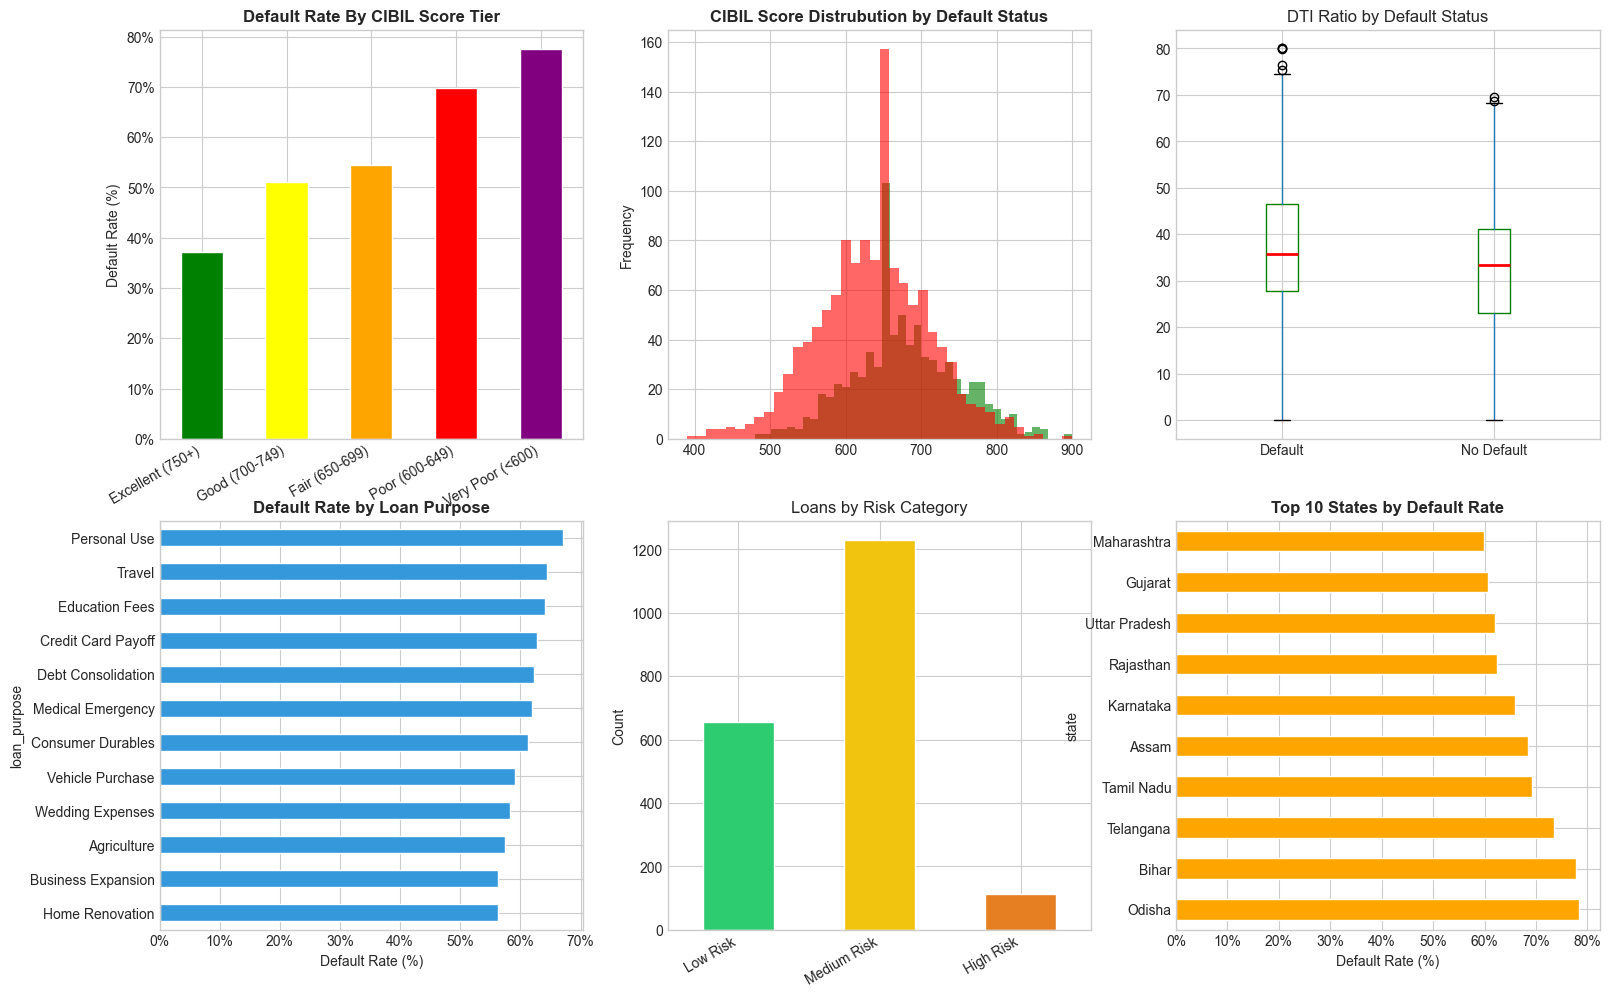

In [96]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Loan Default Risk Analysis - India | EDA Dashboard',
            fontsize=16, fontweight='bold', y=1.01)

orange_palette = ['green', 'yellow', 'orange', 'red', 'purple']
COLORS = {
    "No Default": "green",
    "Default": "red"
}
ax = axes[0,0]
order = ['Excellent (750+)', 'Good (700-749)', 'Fair (650-699)', 'Poor (600-649)', 'Very Poor (<600)']
grp = df_clean.groupby('credit_tier')['default_status'].mean().reindex(order)*100
grp.plot(kind='bar', ax=ax, color=orange_palette, edgecolor='white')
ax.set_title('Default Rate By CIBIL Score Tier', fontweight='bold')
ax.set_ylabel('Default Rate (%)')
ax.set_xlabel('')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

ax = axes[0,1]
df_clean[df_clean['default_status']==0]['credit_score'].plot(kind='hist', bins=40, alpha=0.6,
                                                             color=COLORS['No Default'], ax=ax)
df_clean[df_clean['default_status']==1]['credit_score'].plot(kind='hist', bins=40, alpha=0.6,
                                                             color=COLORS['Default'], ax=ax)
ax.set_title('CIBIL Score Distrubution by Default Status', fontweight='bold')

ax = axes[0,2]
df_clean.boxplot(column='dti_ratio', by='default_label', ax=ax, boxprops=dict(color='green'),
                 medianprops=dict(color='red', linewidth=2))
ax.set_title('DTI Ratio by Default Status', fontweight='bold')
plt.sca(ax); plt.title('DTI Ratio by Default Status'); plt.suptitle('')
ax.set_xlabel('')

ax = axes[1,0]
purpose_dr = df_clean.groupby('loan_purpose')['default_status'].mean().sort_values()*100
purpose_dr.plot(kind='barh', ax=ax, color="#3498DB", edgecolor='white')
ax.set_title('Default Rate by Loan Purpose', fontweight='bold')
ax.set_xlabel('Default Rate (%)')
ax.xaxis.set_major_formatter(mtick.PercentFormatter())

ax = axes[1,1]
risk_cat_count = df_clean['risk_category'].value_counts()
color_risk = ["#2ECC71","#F1C40F","#E67E22","#E74C3C"]
risk_cat_count[['Low Risk', 'Medium Risk', 'High Risk']].plot(kind='bar', ax=ax, color=color_risk, edgecolor='white')
ax.set_title('Loans by Risk Category')
ax.set_xlabel('')
ax.set_ylabel('Count')
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

ax = axes[1,2]
de_stat = df_clean.groupby('state')['default_status'].mean().sort_values(ascending=False).head(10)*100
de_stat.plot(kind='barh', ax=ax, color='orange', edgecolor='white')
ax.set_title('Top 10 States by Default Rate', fontweight='bold')
ax.set_xlabel('Default Rate (%)')
ax.xaxis.set_major_formatter(mtick.PercentFormatter())

In [97]:
df_clean.describe()

,age,months_employed,annual_income_inr,annual_income_stated_inr,loan_amount_inr,interest_rate,loan_term_months,application_date,credit_score,num_credit_lines,...,monthly_income,loan_income_ratio,income_discrepancy_pct,income_mismatch_flag,employment_years,stable_employment,estimated_emi,emi_to_income_ratio,high_risk_flag,risk_score_raw
count,2000.000000,2000.000000,2.000000e+03,2.000000e+03,2.000000e+03,2000.000000,2000.000000,1920,2000.00000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,34.843500,46.838500,5.114025e+05,5.454540e+05,4.699787e+05,12.693515,45.210000,2022-07-09 17:22:30,653.32500,10.265500,...,42616.871000,1.246836,6.938805,0.197500,3.904800,0.625000,4959.245500,0.158937,0.496500,3.459170
min,21.000000,0.000000,1.500000e+05,9.986500e+04,2.739500e+04,8.000000,12.000000,2020-01-01 00:00:00,390.00000,1.000000,...,12500.000000,0.021500,-69.900000,0.000000,0.000000,0.000000,344.000000,0.003200,0.000000,1.040000
25%,27.000000,15.000000,2.983190e+05,2.982355e+05,2.180032e+05,11.140000,36.000000,2021-04-22 18:00:00,605.00000,6.000000,...,24860.250000,0.451975,-4.412500,0.000000,1.200000,0.000000,2272.000000,0.055375,0.000000,2.820000
50%,35.000000,32.000000,4.331045e+05,4.532910e+05,3.545590e+05,12.640000,48.000000,2022-07-10 12:00:00,653.00000,10.000000,...,36092.000000,0.842950,5.435000,0.000000,2.700000,1.000000,3720.000000,0.103750,0.000000,3.380000
75%,41.000000,60.000000,6.298300e+05,6.745530e+05,5.955630e+05,14.260000,60.000000,2023-10-04 00:00:00,700.00000,15.000000,...,52485.750000,1.558775,16.825000,0.000000,5.000000,1.000000,6187.500000,0.197475,1.000000,4.030000
max,65.000000,300.000000,2.864046e+06,3.160884e+06,4.283746e+06,21.620000,84.000000,2024-12-31 00:00:00,900.00000,19.000000,...,238670.000000,20.124000,290.840000,1.000000,25.000000,1.000000,55438.000000,3.125200,1.000000,7.060000
std,9.280413,46.814947,3.306359e+05,3.667866e+05,3.892164e+05,2.261829,18.797036,NaN,76.00068,5.532478,...,27553.001421,1.399400,22.521136,0.398212,3.900445,0.484244,4223.276094,0.187302,0.500113,0.911149


In [98]:
df_clean['default_label']

0       No Default
1          Default
2       No Default
3          Default
4          Default
           ...    
1995       Default
1996    No Default
1997       Default
1998       Default
1999       Default
Name: default_label, Length: 2000, dtype: object

### ── SECTION 5: RISK SCORING MODEL ──────────────────────────────

In [99]:
df_clean.head()

,loan_id,applicant_name,pan_number,age,gender,city,state,education,employment_status,months_employed,...,loan_income_ratio,income_discrepancy_pct,income_mismatch_flag,employment_years,stable_employment,estimated_emi,emi_to_income_ratio,high_risk_flag,risk_score_raw,risk_category
0,LN1000000,Namrata Tripathi,PZVIS6649L,28.0,Female,Surat,Gujarat,Diploma,Contract/Freelance,82.0,...,0.6302,3.34,0,6.8,1,1596.0,0.0727,0,3.10,Medium Risk
1,LN1000001,Varun Khanna,NVVWE0128Y,33.0,Male,Vadodara,Gujarat,Illiterate,Part-Time,39.0,...,0.5364,3.08,0,3.2,1,2043.0,0.0565,0,3.19,Medium Risk
2,LN1000002,Pallavi Kulkarni,XYXRF2848L,27.0,Female,Nagpur,Maharashtra,Professional Degree,Salaried,35.0,...,0.4188,4.86,0,2.9,1,1819.0,0.0488,0,2.11,Low Risk
3,LN1000003,Sonali Oberoi,GHWMW5908Q,31.0,Female,Meerut,Uttar Pradesh,12th Pass,Part-Time,61.0,...,0.4201,16.96,0,5.1,1,2426.0,0.0496,0,2.44,Low Risk
4,LN1000004,Jitendra Bhatt,DRNKW1939O,21.0,Male,Guwahati,Assam,Professional Degree,Retired,0.0,...,1.6003,-4.29,0,0.0,0,4161.0,0.2563,1,4.26,Medium Risk


In [100]:
df_clean.columns

Index(['loan_id', 'applicant_name', 'pan_number', 'age', 'gender', 'city',
       'state', 'education', 'employment_status', 'months_employed',
       'annual_income_inr', 'annual_income_stated_inr', 'property_ownership',
       'loan_amount_inr', 'loan_purpose', 'loan_grade', 'interest_rate',
       'loan_term_months', 'application_date', 'credit_score',
       'num_credit_lines', 'num_open_accounts', 'num_late_payments',
       'dti_ratio', 'bankruptcies', 'loan_to_income_ratio', 'default_status',
       'default_label', 'app_year', 'app_month', 'app_quarter', 'credit_tier',
       'monthly_income', 'loan_income_ratio', 'income_discrepancy_pct',
       'income_mismatch_flag', 'employment_years', 'stable_employment',
       'estimated_emi', 'emi_to_income_ratio', 'high_risk_flag',
       'risk_score_raw', 'risk_category'],
      dtype='object')

In [101]:
features = ["credit_score","dti_ratio","annual_income_inr","loan_amount_inr",
            "num_late_payments","interest_rate","bankruptcies","months_employed",
            "loan_to_income_ratio","emi_to_income_ratio","income_mismatch_flag","stable_employment"]

In [102]:
X = df_clean[features].copy()
y = df_clean["default_status"]
X

,credit_score,dti_ratio,annual_income_inr,loan_amount_inr,num_late_payments,interest_rate,bankruptcies,months_employed,loan_to_income_ratio,emi_to_income_ratio,income_mismatch_flag,stable_employment
0,689.0,34.50,263525.0,166066,2.0,11.54,0,82.0,0.6302,0.0727,0,1
1,638.0,27.45,434207.0,232896,2.0,10.53,0,39.0,0.5364,0.0565,0,1
2,701.0,32.41,447221.0,187317,0.0,11.66,0,35.0,0.4188,0.0488,0,1
3,771.0,45.72,587468.0,246817,1.0,11.80,0,61.0,0.4201,0.0496,0,1
4,631.0,54.17,194830.0,311792,2.0,16.02,0,0.0,1.6003,0.2563,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1995,735.0,54.52,490353.0,1701292,3.0,14.53,0,12.0,3.4695,0.5041,0,0
1996,647.0,5.02,883449.0,455383,1.0,8.30,0,5.0,0.5155,0.0428,0,0
1997,579.0,24.42,213108.0,201876,4.0,13.41,0,32.0,0.9473,0.1270,0,1
1998,653.0,42.44,585821.0,1152033,1.0,12.05,0,27.0,1.9665,0.2369,0,1


In [103]:
imputer = SimpleImputer(strategy="median")
X_imp = imputer.fit_transform(X)
X_imp

array([[6.89000e+02, 3.45000e+01, 2.63525e+05, ..., 7.27000e-02,
        0.00000e+00, 1.00000e+00],
       [6.38000e+02, 2.74500e+01, 4.34207e+05, ..., 5.65000e-02,
        0.00000e+00, 1.00000e+00],
       [7.01000e+02, 3.24100e+01, 4.47221e+05, ..., 4.88000e-02,
        0.00000e+00, 1.00000e+00],
       ...,
       [5.79000e+02, 2.44200e+01, 2.13108e+05, ..., 1.27000e-01,
        0.00000e+00, 1.00000e+00],
       [6.53000e+02, 4.24400e+01, 5.85821e+05, ..., 2.36900e-01,
        0.00000e+00, 1.00000e+00],
       [5.90000e+02, 4.46700e+01, 2.19220e+05, ..., 9.38900e-01,
        0.00000e+00, 1.00000e+00]], shape=(2000, 12))

In [104]:
X_train, X_test, y_train, y_test = train_test_split(X_imp, y, test_size=0.2, random_state=42, stratify=y)

In [105]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

In [106]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_s, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [107]:
y_pred       = model.predict(X_test_s)
y_pred_proba = model.predict_proba(X_test_s)[:,1]
auc          = roc_auc_score(y_test, y_pred_proba)
print(auc)

0.8844577553593947


In [108]:
print(f"\n📊 Model AUC-ROC Score: {auc:.4f}")
print(classification_report(y_test, y_pred, target_names=["No Default","Default"]))

X_all_s = scaler.transform(imputer.transform(df_clean[features]))
df_clean["ml_default_probability"] = model.predict_proba(X_all_s)[:,1].round(4)
df_clean["ml_risk_flag"] = (df_clean["ml_default_probability"] >= 0.60).astype(int)


📊 Model AUC-ROC Score: 0.8845
              precision    recall  f1-score   support

  No Default       0.73      0.71      0.72       156
     Default       0.82      0.84      0.83       244

    accuracy                           0.79       400
   macro avg       0.77      0.77      0.77       400
weighted avg       0.78      0.79      0.78       400



In [109]:
feat_importance = pd.Series(np.abs(model.coef_[0]), index=features).sort_values(ascending=False)
print(f"\nFeature Importance:\n{feat_importance.to_string()}")


Feature Importance:
loan_to_income_ratio    2.455858
bankruptcies            0.828451
credit_score            0.743897
num_late_payments       0.389157
interest_rate           0.335430
dti_ratio               0.310534
emi_to_income_ratio     0.281439
annual_income_inr       0.177602
loan_amount_inr         0.163574
months_employed         0.134010
stable_employment       0.066144
income_mismatch_flag    0.061069


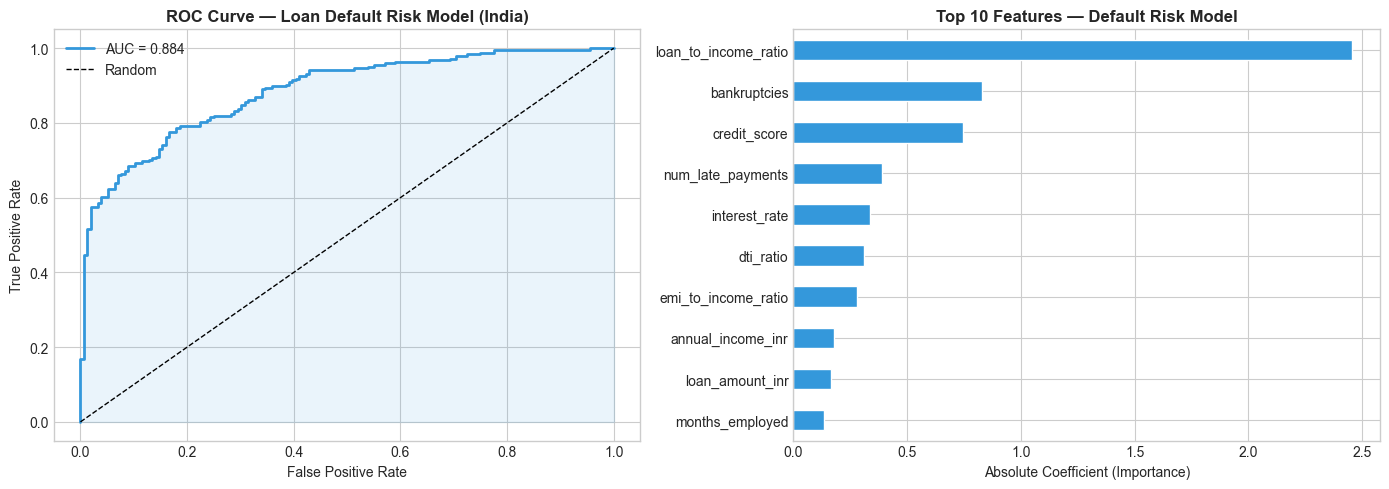

In [110]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.plot(fpr, tpr, color="#3498DB", lw=2, label=f"AUC = {auc:.3f}")
ax.plot([0,1],[0,1],"k--",lw=1,label="Random")
ax.fill_between(fpr, tpr, alpha=0.1, color="#3498DB")
ax.set_title("ROC Curve — Loan Default Risk Model (India)", fontweight="bold")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate"); ax.legend()
ax = axes[1]
feat_importance.head(10).sort_values().plot(kind="barh", ax=ax, color="#3498DB", edgecolor="white")
ax.set_title("Top 10 Features — Default Risk Model", fontweight="bold")
ax.set_xlabel("Absolute Coefficient (Importance)")
plt.tight_layout()

### ── SECTION 6: BUSINESS INSIGHTS ─────────────────────────────────────────────

In [111]:
avg_loan    = df_clean["loan_amount_inr"].mean()
total_loans = len(df_clean)
flagged     = df_clean[df_clean["ml_risk_flag"]==1]
flagged_dr  = flagged["default_status"].mean()
baseline_dr = df_clean["default_status"].mean()

print(f"\n💰 Financial Impact (INR):")
print(f"   Avg Loan Amount         : ₹{avg_loan:,.0f}")
print(f"   Baseline Default Rate   : {baseline_dr:.1%}")
print(f"   ML Flagged Loans        : {len(flagged):,} ({len(flagged)/total_loans:.1%} of portfolio)")
print(f"   Default Rate in Flagged : {flagged_dr:.1%}")


💰 Financial Impact (INR):
   Avg Loan Amount         : ₹469,979
   Baseline Default Rate   : 60.9%
   ML Flagged Loans        : 1,075 (53.8% of portfolio)
   Default Rate in Flagged : 85.7%


In [112]:
assumed_annual_loans = 10000   # typical Indian mid-size bank
assumed_loss_pct     = 0.70    # loss given default in India tends higher
defaults_prevented   = assumed_annual_loans * baseline_dr * 0.15
loss_per_default     = avg_loan * assumed_loss_pct
annual_savings       = defaults_prevented * loss_per_default

print(f"\n   📈 Projected Savings (15% default reduction):")
print(f"   Defaults Prevented : ~{defaults_prevented:.0f} loans/year")
print(f"   Estimated Savings  : ₹{annual_savings:,.0f} (~₹{annual_savings/10000000:.2f} Crore)")


   📈 Projected Savings (15% default reduction):
   Defaults Prevented : ~914 loans/year
   Estimated Savings  : ₹300,527,876 (~₹30.05 Crore)


In [113]:
seg = df_clean.groupby("risk_category").agg(
    Count=("loan_id","count"),
    Avg_Loan_INR=("loan_amount_inr","mean"),
    Avg_CIBIL=("credit_score","mean"),
    Default_Rate=("default_status","mean"),
    Avg_DTI=("dti_ratio","mean")
).round(2)
seg["Default_Rate"] = seg["Default_Rate"].map("{:.1%}".format)
seg["Avg_Loan_INR"] = seg["Avg_Loan_INR"].map("₹{:,.0f}".format)
print(f"\n📊 Borrower Risk Segments:\n{seg.to_string()}")


📊 Borrower Risk Segments:
                Count Avg_Loan_INR  Avg_CIBIL Default_Rate  Avg_DTI
risk_category                                                      
Low Risk          657     ₹379,560     696.55        32.0%    28.28
Medium Risk      1229     ₹501,617     635.44        73.0%    37.82
High Risk         113     ₹650,242     596.58       100.0%    42.56
Very High Risk      1     ₹622,356     645.00       100.0%    60.78


In [115]:
export_cols = [
    "loan_id","applicant_name","pan_number","age","gender","city","state","education",
    "employment_status","months_employed","employment_years","annual_income_inr",
    "annual_income_stated_inr","property_ownership","loan_amount_inr","loan_purpose",
    "loan_grade","interest_rate","loan_term_months","estimated_emi","application_date",
    "app_year","app_month","app_quarter","credit_score","credit_tier","num_credit_lines",
    "num_open_accounts","num_late_payments","dti_ratio","bankruptcies",
    "loan_to_income_ratio","emi_to_income_ratio","monthly_income","income_discrepancy_pct",
    "income_mismatch_flag","stable_employment","risk_score_raw","risk_category",
    "high_risk_flag","ml_default_probability","ml_risk_flag","default_status","default_label"
]

df_clean[export_cols].to_csv(r"C:\Users\tabas\Downloads\End-to-End project\loan_default_clean_analysed.csv", index=False)
print("\n✅ Exported: loan_default_clean_analysed.csv")
print("\n✅ INDIA ANALYSIS COMPLETE")


✅ Exported: loan_default_clean_analysed.csv

✅ INDIA ANALYSIS COMPLETE
